In [1]:
# #| eval: false

# ============================================================
# Lectura de NetCDF con múltiples bandas usando {stars}
# + Gestión de directorio local ./data_heavy/
# + Conversión de tiempo a fechas reales
# + Asignación de CRS WGS84
# ============================================================

# -------------------------------
# 1. Cargar librerías necesarias
# -------------------------------
library(stars)     # Manejo de datos raster multidimensionales

Loading required package: abind

Loading required package: sf

Linking to GEOS 3.12.1, GDAL 3.8.4, PROJ 9.4.0; sf_use_s2() is TRUE



In [2]:
library(units)     # Manejo de unidades

udunits database from /usr/share/xml/udunits/udunits2.xml



In [3]:
# -------------------------------
# 2. Configuración de rutas
# -------------------------------
data_dir <- "./data_heavy/"

# Crear el directorio si no existe
if (!dir.exists(data_dir)) {
  dir.create(data_dir, recursive = TRUE)
  message(paste("Directorio creado:", data_dir))
}

# Definición de rutas completas
url <- "http://geocorp.co/wind/goodland_10u_1.zip"
zip_file <- file.path(data_dir, "10fg_2017_2018.zip")
nc_file <- file.path(data_dir, "goodland_10u_1.nc")

# -------------------------------
# 3. Descargar y descomprimir datos
# -------------------------------
# Descargar solo si el archivo NO existe en la ruta destino
if (!file.exists(zip_file)) {
  message("Iniciando descarga...")
  download.file(url, zip_file, mode = "wb")
} else {
  message("El archivo zip ya existe en el directorio de datos.")
}

Directorio creado: ./data_heavy/

Iniciando descarga...



In [4]:
# Descomprimir específicamente en el directorio indicado
unzip(zip_file, exdir = data_dir)

# -------------------------------
# 4. Configuración de entorno y lectura
# -------------------------------
# Ajuste de límite de bandas para series temporales extensas
Sys.setenv(GDAL_MAX_BAND_COUNT = 120000)

# Lectura del archivo desde la ruta procesada
if (file.exists(nc_file)) {
  y <- read_stars(nc_file, quiet = TRUE)
  print(y)
  y
} else {
  stop("Archivo .nc no encontrado en la ruta especificada.")
}

stars object with 3 dimensions and 1 attribute
attribute(s), summary of first 1e+05 cells:
                             Min.    1st Qu.   Median      Mean  3rd Qu.
goodland_10u_1.nc [m/s] -6.195632 -0.8395011 1.254741 0.9318181 2.778291
                            Max.
goodland_10u_1.nc [m/s] 8.446477
dimension(s):
     from     to offset delta  refsys
x       1      9 -102.7  0.25      NA
y       1      9  40.62 -0.25      NA
time    1 113232     NA    NA udunits
                                                                                                          values
x                                                                                                           NULL
y                                                                                                           NULL
time [692496,692497) [hours since 1900-01-01 00:00:00.0],...,[815231,815232) [hours since 1900-01-01 00:00:00.0]
     x/y
x    [x]
y    [y]
time    


stars object with 3 dimensions and 1 attribute
attribute(s), summary of first 1e+05 cells:
                             Min.    1st Qu.   Median      Mean  3rd Qu.
goodland_10u_1.nc [m/s] -6.195632 -0.8395011 1.254741 0.9318181 2.778291
                            Max.
goodland_10u_1.nc [m/s] 8.446477
dimension(s):
     from     to offset delta  refsys
x       1      9 -102.7  0.25      NA
y       1      9  40.62 -0.25      NA
time    1 113232     NA    NA udunits
                                                                                                          values
x                                                                                                           NULL
y                                                                                                           NULL
time [692496,692497) [hours since 1900-01-01 00:00:00.0],...,[815231,815232) [hours since 1900-01-01 00:00:00.0]
     x/y
x    [x]
y    [y]
time    

In [ ]:
Con simple feature se puede asignar el sistema de coordenadas

In [5]:
# -------------------------------
# 5. Asignar sistema de referencia (CRS)
# -------------------------------

# Según los valores de coordenadas:
# x ≈ longitudes (-102.7, etc.)
# y ≈ latitudes (40.62, etc.)
# → corresponde a WGS84 (EPSG:4326)

st_crs(y) <- 4326  # Asignación directa
y

stars object with 3 dimensions and 1 attribute
attribute(s), summary of first 1e+05 cells:
                             Min.    1st Qu.   Median      Mean  3rd Qu.
goodland_10u_1.nc [m/s] -6.195632 -0.8395011 1.254741 0.9318181 2.778291
                            Max.
goodland_10u_1.nc [m/s] 8.446477
dimension(s):
     from     to offset delta  refsys
x       1      9 -102.7  0.25  WGS 84
y       1      9  40.62 -0.25  WGS 84
time    1 113232     NA    NA udunits
                                                                                                          values
x                                                                                                           NULL
y                                                                                                           NULL
time [692496,692497) [hours since 1900-01-01 00:00:00.0],...,[815231,815232) [hours since 1900-01-01 00:00:00.0]
     x/y
x    [x]
y    [y]
time    

In [6]:
# -------------------------------
# 6. Convertir dimensión temporal a fechas reales
# -------------------------------

# Extraer dimensión tiempo
time_vals <- st_get_dimension_values(y, "time")

# Ver unidades del tiempo
attr(time_vals, "units")

$numerator
[1] "hours since 1900-01-01 00:00:00.0"

$denominator
character(0)

attr(,"class")
[1] "symbolic_units"

In [7]:
# En este caso:
# "hours since 1900-01-01 00:00:00"

# Convertir a POSIXct (fechas reales)
time_real <- as.POSIXct(
  time_vals,
  origin = "1900-01-01",
  tz = "UTC"
)

# Reemplazar dimensión en el objeto stars
st_set_dimensions(y, "time", values = time_real) -> y

# -------------------------------
# 7. Verificar resultado
# -------------------------------
y

stars object with 3 dimensions and 1 attribute
attribute(s), summary of first 1e+05 cells:
                             Min.    1st Qu.   Median      Mean  3rd Qu.
goodland_10u_1.nc [m/s] -6.195632 -0.8395011 1.254741 0.9318181 2.778291
                            Max.
goodland_10u_1.nc [m/s] 8.446477
dimension(s):
     from     to offset delta  refsys                             values x/y
x       1      9 -102.7  0.25  WGS 84                               NULL [x]
y       1      9  40.62 -0.25  WGS 84                               NULL [y]
time    1 113232     NA    NA POSIXct 1979-01-01,...,1992-12-31 23:00:00    

In [8]:
# Revisar primeras fechas
head(st_get_dimension_values(y, "time"))

[1] "1979-01-01 00:00:00 UTC" "1979-01-01 01:00:00 UTC"
[3] "1979-01-01 02:00:00 UTC" "1979-01-01 03:00:00 UTC"
[5] "1979-01-01 04:00:00 UTC" "1979-01-01 05:00:00 UTC"

In [10]:
# -------------------------------
# 8. Ejemplo: extraer un tiempo específico
# -------------------------------

# Índice temporal que quieres graficar
i <- 1

# Seleccionar primer instante temporal
## as tres primeras comas son de los atributos, los x y los y que son los primeros datos de la variable y stars
y_ti <- y[,,,i]

# Obtener la fecha correspondiente
fecha_i <- st_get_dimension_values(y, "time")[i]


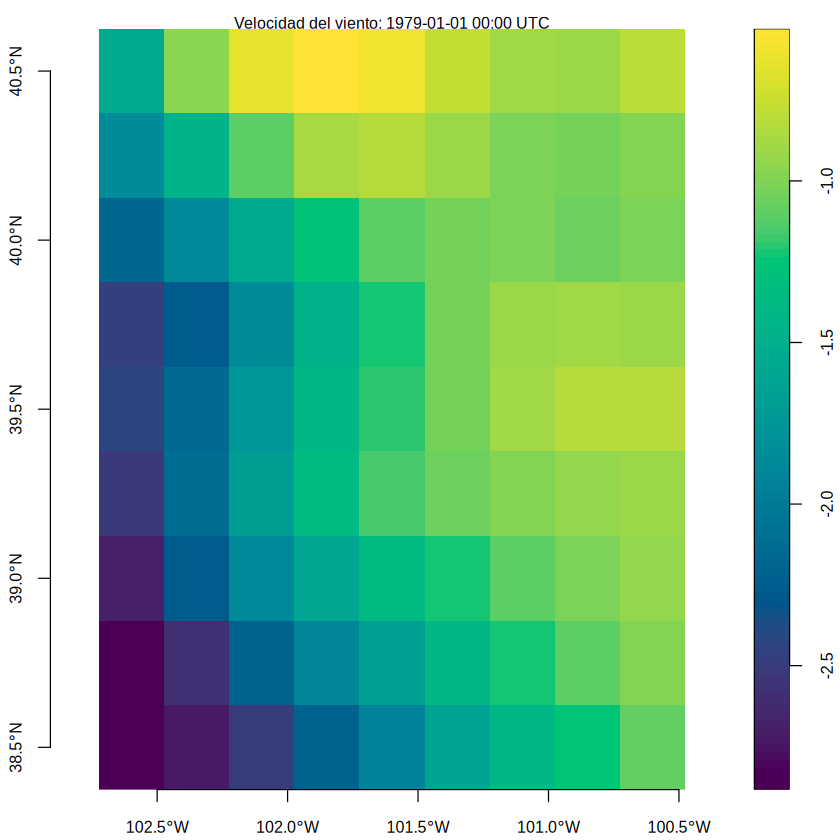

In [11]:

# Crear título dinámico
titulo <- paste0(
  "Velocidad del viento: ",
  format(fecha_i, "%Y-%m-%d %H:%M UTC")
)

# -------------------------------
# Configuración de paleta y cortes
# -------------------------------
# Viridis es perceptualmente uniforme y coincide con la estética de Python
#pal <- hcl.colors(100, "YlGnBu", rev = TRUE)
pal <- hcl.colors(100, "Viridis") 

valores <- as.vector(y_ti[[1]])
brks <- seq(min(valores, na.rm = TRUE),
            max(valores, na.rm = TRUE),
            length.out = length(pal) + 1)

# -------------------------------
# Graficación mejorada
# -------------------------------
# Se aumenta key.width para legibilidad y se ajustan márgenes
par(mar = c(
  4,  # Margen inferior: suficiente espacio para etiquetas del eje X
  4,  # Margen izquierdo: espacio para etiquetas del eje Y
  5,  # Margen superior: espacio para el título (un poco más compacto)
  1   # Margen derecho: mínimo (útil si la leyenda está fuera o no es grande)
))


plot(
  y_ti,                  # Objeto stars a graficar
  col = pal,             # Paleta de colores
  main = "",             # Título del gráfico
  breaks = brks,         # Intervalos de valores (deben ser length(col) + 1)
  key.pos = 4,           # Posición de la leyenda (4 = derecha, 1 = abajo, ...)
  key.width = lcm(2),    # Ancho de la barra de la leyenda (en cm)
  key.length = 1,        # Longitud relativa de la leyenda (escala vertical)
  axes = TRUE,           # Mostrar ejes (coordenadas X e Y)
  reset = FALSE,         # Para poder añadir elementos después
  cex.axis = 0.8         # Tamaño de fuente en ejes
)


# Adición de etiquetas de eje de forma manual para mayor claridad
title(
  main = titulo,     # Texto del título principal
  cex.main = 0.8,    # Tamaño del título (1 = normal; 1.2 = 20% más grande)
  font.main = 1,     # Tipo de fuente del título (1 = normal, 2 = negrita, 
                     #                   3 = cursiva, 4 = negrita+cursiva)
  line = 0           # Ajustar según necesidad para evitar solapamiento                     
)
title(
  xlab = "Longitude [degrees_east]",  # Etiqueta del eje X
  line = 2.5                          # Distancia vertical desde el eje X 
                                      # hacia abajo (en líneas de texto);
                                      # valores mayores → más separado del eje
)
title(ylab = "Latitude [degrees_north]", line = 2.5)

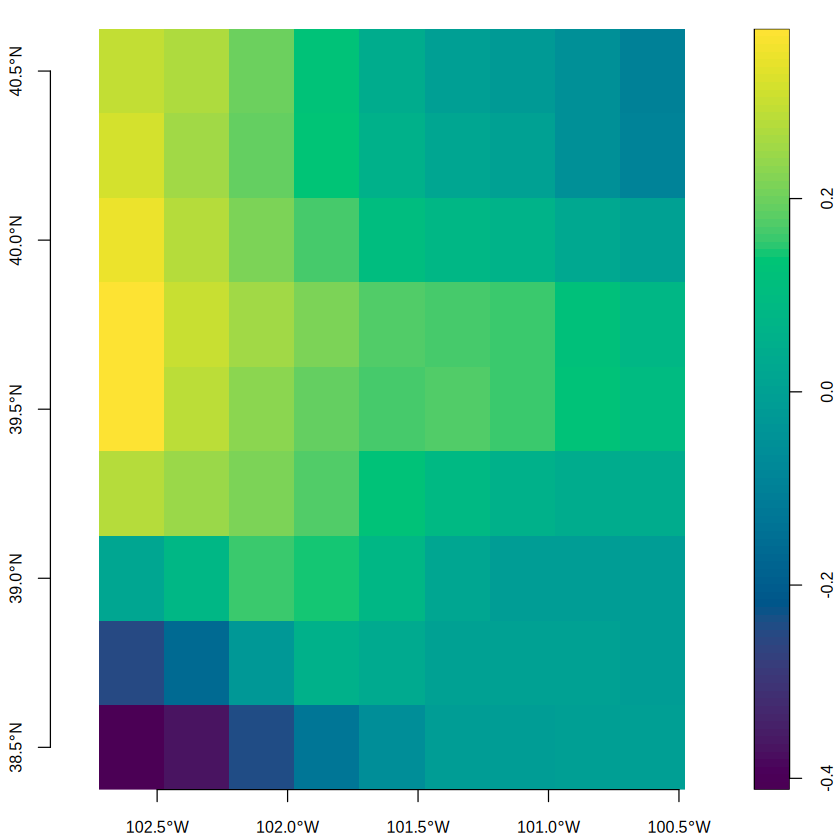

In [14]:
# -------------------------------
# 9. Ejemplo: promedio temporal
# -------------------------------

# Calcular media a lo largo del tiempo
y_mean <- st_apply(y, c("x", "y"), mean, na.rm = TRUE)


pal <- hcl.colors(100, "Viridis") 
valores <- as.vector(y_mean[[1]])
brks <- seq(min(valores, na.rm = TRUE),
            max(valores, na.rm = TRUE),
            length.out = length(pal) + 1)

par(mar = c(4, 4, 7, 1))

titulo = "Velocidad promedio del viento"

plot(
  y_mean,                # Objeto stars a graficar
  col = pal,             # Paleta de colores
  main = "",             # Título del gráfico
  breaks = brks,         # Intervalos de valores (deben ser length(col) + 1)
  key.pos = 4,           # Posición de la leyenda (4 = derecha, 1 = abajo, ...)
  key.width = lcm(2),    # Ancho de la barra de la leyenda (en cm)
  key.length = 1,        # Longitud relativa de la leyenda (escala vertical)
  axes = TRUE,           # Mostrar ejes (coordenadas X e Y)
  reset = FALSE,         # Para poder añadir elementos después
  cex.axis = 0.8         # Tamaño de fuente en ejes
)

# Adición de etiquetas de eje de forma manual para mayor claridad
title(
  main = titulo,     # Texto del título principal
  cex.main = 0.8,    # Tamaño del título (1 = normal; 1.2 = 20% más grande)
  font.main = 1,     # Tipo de fuente del título (1 = normal, 2 = negrita, 
                     #                   3 = cursiva, 4 = negrita+cursiva)
  line = 2           # Ajustar según necesidad para evitar solapamiento
)
title(
  xlab = "Longitude [degrees_east]",  # Etiqueta del eje X
  line = 2.5                          # Distancia vertical desde el eje X 
                                      # hacia abajo (en líneas de texto);
                                      # valores mayores → más separado del eje
)
title(ylab = "Latitude [degrees_north]", line = 2.5)

In [ ]:
## Verificación de los niveles de presión y su correspondencia


In [26]:
# #| eval: false

# -------------------------------------------------------------------------
# Librerías
# -------------------------------------------------------------------------
library(stars)
library(dplyr)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [28]:
library(sf)

# Ajuste de variables de entorno de GDAL
# Se incrementa el límite de bandas para permitir el procesamiento de cubos 5D 
# con una densidad temporal o vertical elevada (ej. ERA5 o modelos climáticos).
Sys.setenv(GDAL_MAX_BAND_COUNT = 1200000)

# -------------------------------------------------------------------------
# Rutas y nombres de archivos
# -------------------------------------------------------------------------

path     <- "../data_heavy/"
ncname   <- "download5Dcolombia"
ncfile5d <- paste0(path, ncname, ".nc")
zipfile  <- paste0(path, ncname, ".zip")

# -------------------------------------------------------------------------
# Control de existencia y descompresión de archivos
# -------------------------------------------------------------------------

if (!file.exists(ncfile5d)) {

  if (file.exists(zipfile)) {
    message("Descomprimiendo archivo...")
    unzip(zipfile, exdir = path)
  } else {
    stop("No existe .nc ni .zip")
  }

} else {
  message("Usando archivo existente")
}

Usando archivo existente



In [29]:
# -------------------------------------------------------------------------
# Carga lazy
# -------------------------------------------------------------------------

# Lectura mediante proxy=TRUE para manipulación diferida (lazy evaluation).
# Esto permite definir recortes espaciales y temporales sin cargar todo el 
# archivo.
st_col5d = read_stars(ncfile5d, proxy=TRUE)

Warning message in CPL_get_metadata(file, NA_character_, options):
“GDAL Message 1: dimension #1 (number) is not a Time dimension.”
Warning message in CPL_read_gdal(as.character(x), as.character(options), as.character(driver), :
“GDAL Message 1: The dataset has several variables that could be identified as vector fields, but not all share the same primary dimension. Consequently they will be ignored.”
Warning message in CPL_read_gdal(as.character(x), as.character(options), as.character(driver), :
“GDAL Message 1: dimension #1 (number) is not a Time dimension.”


In [30]:

# Chequeto de CRS
st_crs(st_col5d)

Coordinate Reference System: NA

In [33]:
# Asignación de CRS en {stars}
# Opción 1: Asignación directa (reemplaza el NA en el objeto existente)
#st_crs(st_col5d) <- 4326
# Opción 2: Usando st_set_crs (estilo funcional/pipe)
st_col5d <- st_col5d %>% st_set_crs(4326)
#st_col5d <- st_set_crs(st_col5d, 4326)

cat("\n=== DATASET ===\n")
print(st_col5d)


=== DATASET ===
stars_proxy object with 1 attribute in 1 file(s):
$download5Dcolombia.nc
[1] "[...]/download5Dcolombia.nc"

dimension(s):
       from  to                                      offset
x         1  25                                      -79.35
y         1  35                                       12.75
level     1  37                                          NA
number    1  10                                           0
time      1 480 1051896 [hours since 1900-01-01 00:00:00.0]
                                       delta  refsys
x                                        0.5  WGS 84
y                                       -0.5  WGS 84
level                                     NA udunits
number                                     1      NA
time   3 [hours since 1900-01-01 00:00:00.0] udunits
                                              values x/y
x                                               NULL [x]
y                                               NULL [y]
level  [1,2)

In [34]:
# -------------------------------------------------------------------------
# Dimensiones
# -------------------------------------------------------------------------

cat("\n=== DIMENSIONES ===\n")
print(st_dimensions(st_col5d))


=== DIMENSIONES ===
       from  to                                      offset
x         1  25                                      -79.35
y         1  35                                       12.75
level     1  37                                          NA
number    1  10                                           0
time      1 480 1051896 [hours since 1900-01-01 00:00:00.0]
                                       delta  refsys
x                                        0.5  WGS 84
y                                       -0.5  WGS 84
level                                     NA udunits
number                                     1      NA
time   3 [hours since 1900-01-01 00:00:00.0] udunits
                                              values x/y
x                                               NULL [x]
y                                               NULL [y]
level  [1,2) [millibars],...,[1000,1025) [millibars]    
number                                          NULL    
time            

In [38]:
# #| eval: false

library(stars)
library(dplyr)
library(sf)
library(ggplot2)

# ============================================================
# Selección avanzada en cubo 5D (ERA5) con {stars}
# - Selección por dimensiones
# - Recorte espacial (Bogotá)
# - Extracción de variable
# - Reducción a slice 2D + Visualización
# ============================================================

# -------------------------------------------------------------------------
# Selección de atributos mediante indexación posicional
# -------------------------------------------------------------------------
# El filtrado se realiza sobre las dimensiones del cubo (atributos, x, y, level, number, time).
# st_as_stars() materializa el recorte en memoria tras la selección.
# pero la indexación posicional no funciona, porque internamente
# el orden de las dimensiones puede ser diferente a como se despliega en el objeto stars
# mySel1 <- st_as_stars(st_col5d[         , 1:25,   1:35,   1:2,      1, 1   ])
# mySel1 <- st_as_stars(st_col5d[ atributo,    x,      y, level, number, time])
# mySel1 <- st_as_stars(st_col5d[,1:25,1:35,1:2,1,1])


# Simplificación de la estructura
# adrop() elimina dimensiones unitarias (longitud 1) generadas tras la selección.
# mySel1 <- mySel1 %>% adrop()

# -------------------------------------------------------------------------
# Selección 1: Subconjunto por dimensiones.
#              Mediante verbos de dplyr.
# -------------------------------------------------------------------------
# Selecciona:
# - niveles 1 y 2
# - miembro de ensamble 1
# - tiempo 1

sel_dim <- st_col5d %>% 
  slice(level, 1:2) %>% 
  slice(number, 1) %>% 
  slice(time, 1)

# Materializa en memoria
sel_dim <- st_as_stars(sel_dim)

Warning message in CPL_get_metadata(file, NA_character_, options):
“GDAL Message 1: dimension #1 (number) is not a Time dimension.”
Warning message in CPL_read_gdal(as.character(x), as.character(options), as.character(driver), :
“GDAL Message 1: The dataset has several variables that could be identified as vector fields, but not all share the same primary dimension. Consequently they will be ignored.”
Warning message in CPL_read_gdal(as.character(x), as.character(options), as.character(driver), :
“GDAL Message 1: dimension #1 (number) is not a Time dimension.”


In [39]:
sel_dim

stars object with 3 dimensions and 1 attribute
attribute(s):
                              Min.  1st Qu.   Median     Mean  3rd Qu.     Max.
download5Dcolombia.nc [K] 246.5078 251.7021 256.4746 257.2614 263.3567 265.8842
dimension(s):
      from to offset delta  refsys                               values x/y
x        1 25 -79.35   0.5  WGS 84                                 NULL [x]
y        1 35  12.75  -0.5  WGS 84                                 NULL [y]
level    1  2     NA    NA udunits [1,2) [millibars], [2,3) [millibars]    

In [40]:
# -------------------------------------------------------------------------
# Selección 2: Recorte espacial (Bogotá)
# -------------------------------------------------------------------------
# Bounding box en WGS84

bog_bbox <- st_bbox(
  c(xmin = -74.25, ymin = 4.45,
    xmax = -73.90, ymax = 4.85),
  crs = st_crs(4326)
)

# Recorte espacial sobre el proxy
# Nota: Ambos objetos deben tener el mismo CRS
sel_bogota <- st_crop(st_col5d, bog_bbox)
sel_bogota <- st_as_stars(sel_bogota)

Warning message in CPL_get_metadata(file, NA_character_, options):
“GDAL Message 1: dimension #1 (number) is not a Time dimension.”
Warning message in CPL_read_gdal(as.character(x), as.character(options), as.character(driver), :
“GDAL Message 1: The dataset has several variables that could be identified as vector fields, but not all share the same primary dimension. Consequently they will be ignored.”
Warning message in CPL_read_gdal(as.character(x), as.character(options), as.character(driver), :
“GDAL Message 1: dimension #1 (number) is not a Time dimension.”


In [41]:
sel_bogota

stars object with 5 dimensions and 1 attribute
attribute(s):
                              Min. 1st Qu.   Median     Mean  3rd Qu.     Max.
download5Dcolombia.nc [K] 186.1205 226.303 259.9218 254.9801 288.8509 303.3165
dimension(s):
       from  to                                      offset
x        11  11                                      -79.35
y        16  17                                       12.75
level     1  37                                          NA
number    1  10                                           0
time      1 480 1051896 [hours since 1900-01-01 00:00:00.0]
                                       delta  refsys
x                                        0.5  WGS 84
y                                       -0.5  WGS 84
level                                     NA udunits
number                                     1      NA
time   3 [hours since 1900-01-01 00:00:00.0] udunits
                                              values x/y
x                               

In [42]:
# -------------------------------------------------------------------------
# Slice 2D
# -------------------------------------------------------------------------
# Selecciona:
# - último nivel
# - ensamble 1
# - tiempo 1

capa_2d <- sel_bogota %>%
  slice(level, length(st_get_dimension_values(st_col5d, "level"))) %>%
  slice(number, 1) %>%
  slice(time, 1) %>%
  adrop() # borra dimensiones unitarias

capa_2d

stars object with 2 dimensions and 1 attribute
attribute(s):
                              Min.  1st Qu.  Median    Mean  3rd Qu.     Max.
download5Dcolombia.nc [K] 299.0198 299.1434 299.267 299.267 299.3906 299.5142
dimension(s):
  from to offset delta refsys x/y
x   11 11 -79.35   0.5 WGS 84 [x]
y   16 17  12.75  -0.5 WGS 84 [y]

In [43]:
# Alternativa mediante indexación de atributos
print(capa_2d[[1]])

Units: [K]
         [,1]     [,2]
[1,] 299.5142 299.0198


In [44]:
# Verificación de las dimensiones restantes (nombres)
print(names(st_dimensions(capa_2d)))

[1] "x" "y"


In [45]:
# Extracción de los valores de longitud (x) y latitud (y)
# Se asume que las dimensiones se llaman "x" e "y" tras el procesamiento
eje_x <- st_get_dimension_values(capa_2d, "x")
eje_y <- st_get_dimension_values(capa_2d, "y")

print(eje_x)

[1] -74.1


In [46]:
print(eje_y)

[1] 5.0 4.5


In [47]:
# Verificación y extracción robusta
dimensiones_nombres <- names(st_dimensions(capa_2d))

for (dim in dimensiones_nombres) {
  valores <- st_get_dimension_values(capa_2d, dim)
  cat(paste0("Valores en la dimensión ", dim, ": "), paste(valores, collapse = ", "), "\n")
}

Valores en la dimensión x:  -74.0999984741211 
Valores en la dimensión y:  5, 4.5 


In [53]:
# -------------------------------------------------------------------------
# Plot simple según tamaño del objeto stars
# -------------------------------------------------------------------------

# -------------------------------------------------------------------------
# Control de renderizado para resolución espacial baja y variables con unidades
# -------------------------------------------------------------------------
library(viridis)

Resolución espacial baja. Renderizando matriz nativa sin unidades.



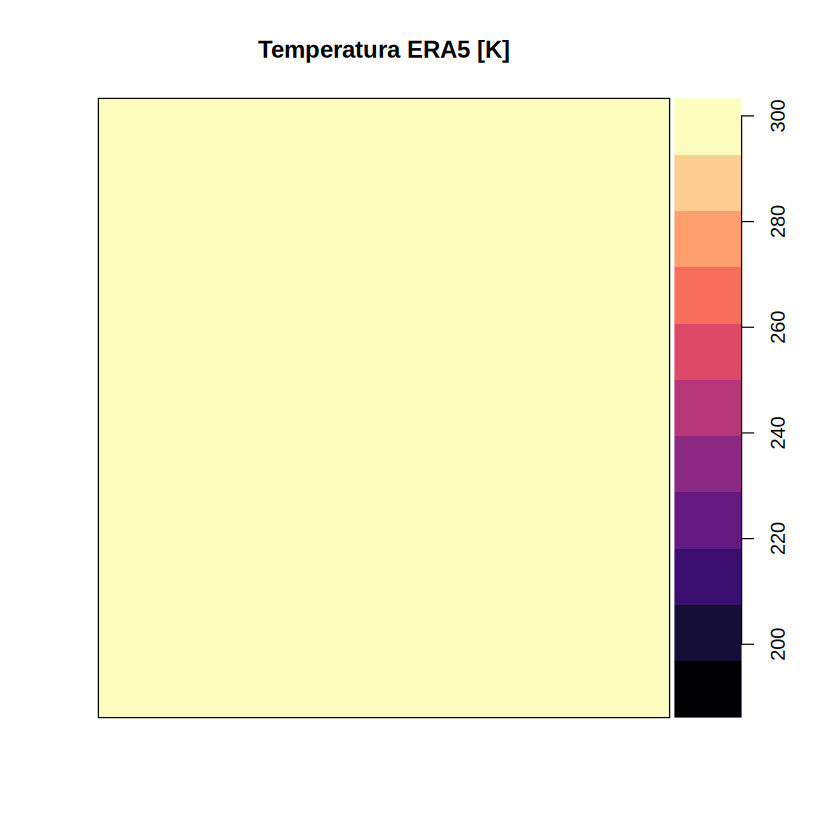

In [54]:
# 1. Recuperar dimensiones
dim_x <- dim(capa_2d)["x"]
dim_y <- dim(capa_2d)["y"]

if (dim_x >= 2 && dim_y >= 2) {
  
  plot(capa_2d[1], 
       main = "Temperatura ERA5 - Bogotá [K]", 
       col = paleta_colores, 
       breaks = cortes_leyenda, 
       key.pos = 4)
       
} else {
  
  message("Resolución espacial baja. Renderizando matriz nativa sin unidades.")
  
  # -------------------------------------------------------------------------
  # Control de renderizado de matriz nativa aplicando el rango global
  # -------------------------------------------------------------------------
  library(viridis)
    
  # 1. Definir rango global (del stars original sel_bogota)
  rango_global <- range(sel_bogota[[1]], na.rm = TRUE)
    
  # 2. Remover la clase 'units' (ej. [K]) para evitar conflictos con image() nativo
  rango_num <- as.numeric(rango_global)
    
  # 3. Extraer valores y asegurar estructura de matriz puramente numérica
  matriz_valores <- as.numeric(drop(capa_2d[[1]]))
  matriz_valores <- matrix(matriz_valores, nrow = dim_x, ncol = dim_y)
    
  # 4. Configurar la paleta de colores
  paleta_colores <- viridis::magma(11)
    
  # Dividir la ventana gráfica: 80% para el mapa, 20% para la leyenda
  layout(matrix(1:2, ncol = 2), widths = c(4, 1))
    
  # --- PANEL 1: MAPA ---
  par(mar = c(5, 4, 4, 0) + 0.1)
    
  # Se utiliza zlim = rango_num para obligar a que los colores de la matriz 
  # se mapeen estrictamente dentro del rango global, no del local.
  image(z = matriz_valores, 
        main = "Temperatura ERA5 [K]", 
        col = paleta_colores, 
        zlim = rango_num, 
        axes = FALSE)
  box()
    
  # --- PANEL 2: LEYENDA ---
  par(mar = c(5, 0, 4, 4) + 0.1)
    
  # Se construye el eje de la leyenda basándose en el rango global numérico
  eje_leyenda <- seq(rango_num[1], rango_num[2], length.out = length(paleta_colores) + 1)
    
  image(x = 1, 
        y = eje_leyenda, 
        z = t(as.matrix(eje_leyenda[-1])), 
        col = paleta_colores, 
        zlim = rango_num, 
        axes = FALSE, 
        xlab = "", 
        ylab = "")
    
  # Añadir los valores del rango global en el eje derecho
  axis(4) 
    
  # Restaurar la configuración de la ventana gráfica
  layout(1)
  par(mar = c(5, 4, 4, 2) + 0.1)
}

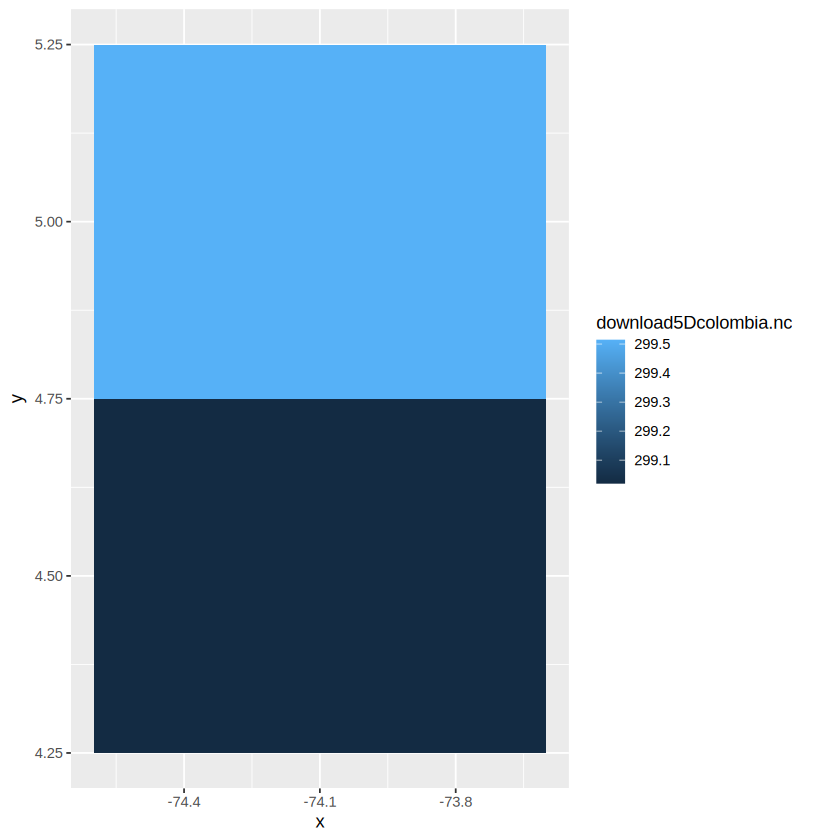

In [55]:
ggplot() +
  # geom_stars extrae automáticamente las coordenadas y el valor del píxel
  geom_stars(data = capa_2d)